# makeshift — quick start

The core workflow: fetch a BMRB entry, get tidy chemical shifts, simulate an HSQC, handle multi-entity entries, and compute the Chemical Shift Index (CSI).

In [1]:
import makeshift as ms
from makeshift.spectra.plotting import plot_peaklist, plot_csp

import seaborn as sns
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


## 1. Fetch a BMRB entry

`ChemicalShifts.from_bmrb` downloads the NMR-STAR file and parses it into a tidy dataframe — one row per chemical shift, in `cs.data`.

In [2]:
# Unphosphorylated NtrCr (Volkman & Kern 2001)
cs = ms.ChemicalShifts.from_bmrb(4527)
cs.data.head()

,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,ChemShift_ID,Sample_ID
0,1,2,<NA>,GLN,CA,C,55.70,chemical_shift_set_1,1
1,1,2,<NA>,GLN,HA,H,4.52,chemical_shift_set_1,1
2,1,2,<NA>,GLN,CB,C,30.00,chemical_shift_set_1,1
3,1,2,<NA>,GLN,HB2,H,2.12,chemical_shift_set_1,1
4,1,2,<NA>,GLN,HB3,H,2.03,chemical_shift_set_1,1


`.peaklist().data` converts the data into a row-per-residue format. Default atom types are H, N, but any can be passed with `dims`.

In [3]:
cs.peaklist().data

,Seq_ID,Auth_seq_ID,Comp_ID,H_ppm,N_ppm,assn_label
0,3,<NA>,ARG,8.58,121.6,R3
1,4,<NA>,GLY,8.14,108.2,G4
2,5,<NA>,ILE,9.69,122.7,I5
3,6,<NA>,VAL,9.18,127.6,V6
4,7,<NA>,TRP,8.60,127.5,W7
...,...,...,...,...,...,...
101,120,<NA>,SER,7.96,114.8,S120
102,121,<NA>,HIS,8.05,119.8,H121
103,122,<NA>,TYR,7.86,118.4,Y122
104,123,<NA>,GLN,7.98,121.4,Q123


In [10]:
cs.peaklist(dims=("CA", "CB")).data

,Seq_ID,Auth_seq_ID,Comp_ID,CA_ppm,CB_ppm,assn_label
0,2,<NA>,GLN,55.7,30.0,Q2
1,3,<NA>,ARG,56.2,31.5,R3
2,5,<NA>,ILE,60.7,39.8,I5
3,6,<NA>,VAL,59.6,34.7,V6
4,7,<NA>,TRP,53.0,33.4,W7
...,...,...,...,...,...,...
103,120,<NA>,SER,60.1,63.5,S120
104,121,<NA>,HIS,57.5,29.4,H121
105,122,<NA>,TYR,58.8,38.8,Y122
106,123,<NA>,GLN,55.7,29.9,Q123


Key columns: `Seq_ID` (residue number), `Comp_ID` (3-letter residue), `Atom_ID`, `Atom_type` (element), `Val` (shift, ppm), `Entity_ID`.

## 2. Simulate an HSQC

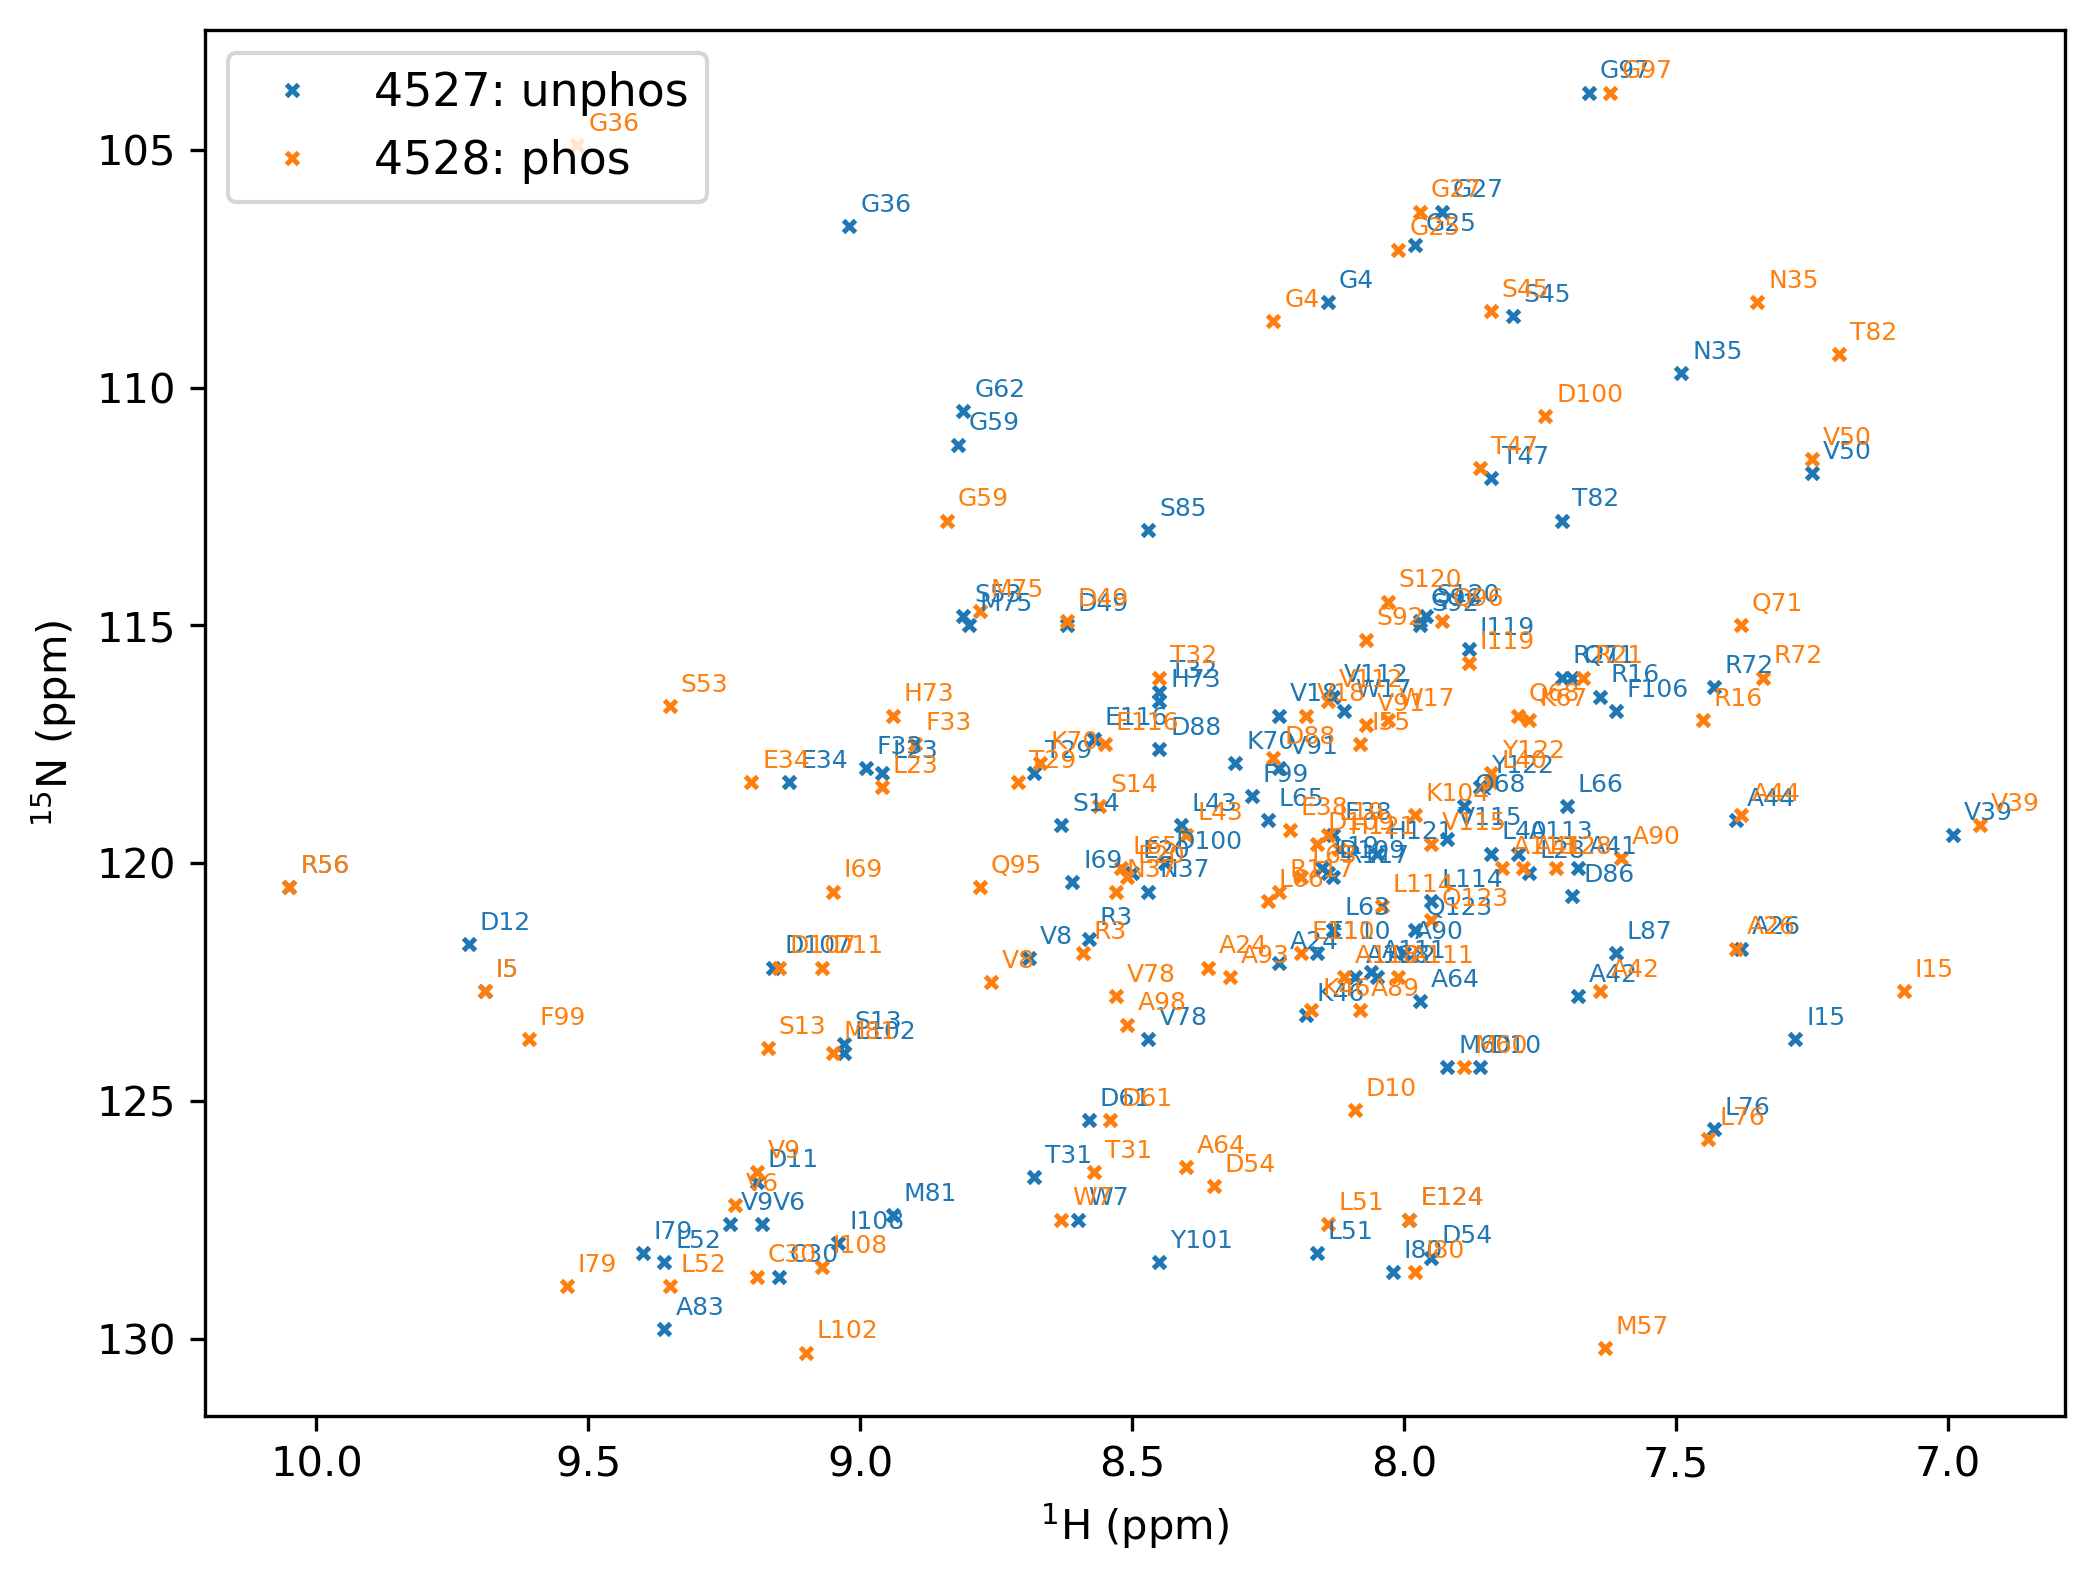

In [2]:
cs = ms.ChemicalShifts.from_bmrb(4527) #unphosphorylated
cs_phos = ms.ChemicalShifts.from_bmrb(4528) #phosphorylated

fig, ax = plot_peaklist(cs.peaklist().data, text='assn_label', color='tab:blue', label='4527: unphos')
_ = plot_peaklist(cs_phos.peaklist().data, ax, text='assn_label', color='tab:orange', label='4528: phos')

plot perturbations between two peaklists with `plot_csp`: 

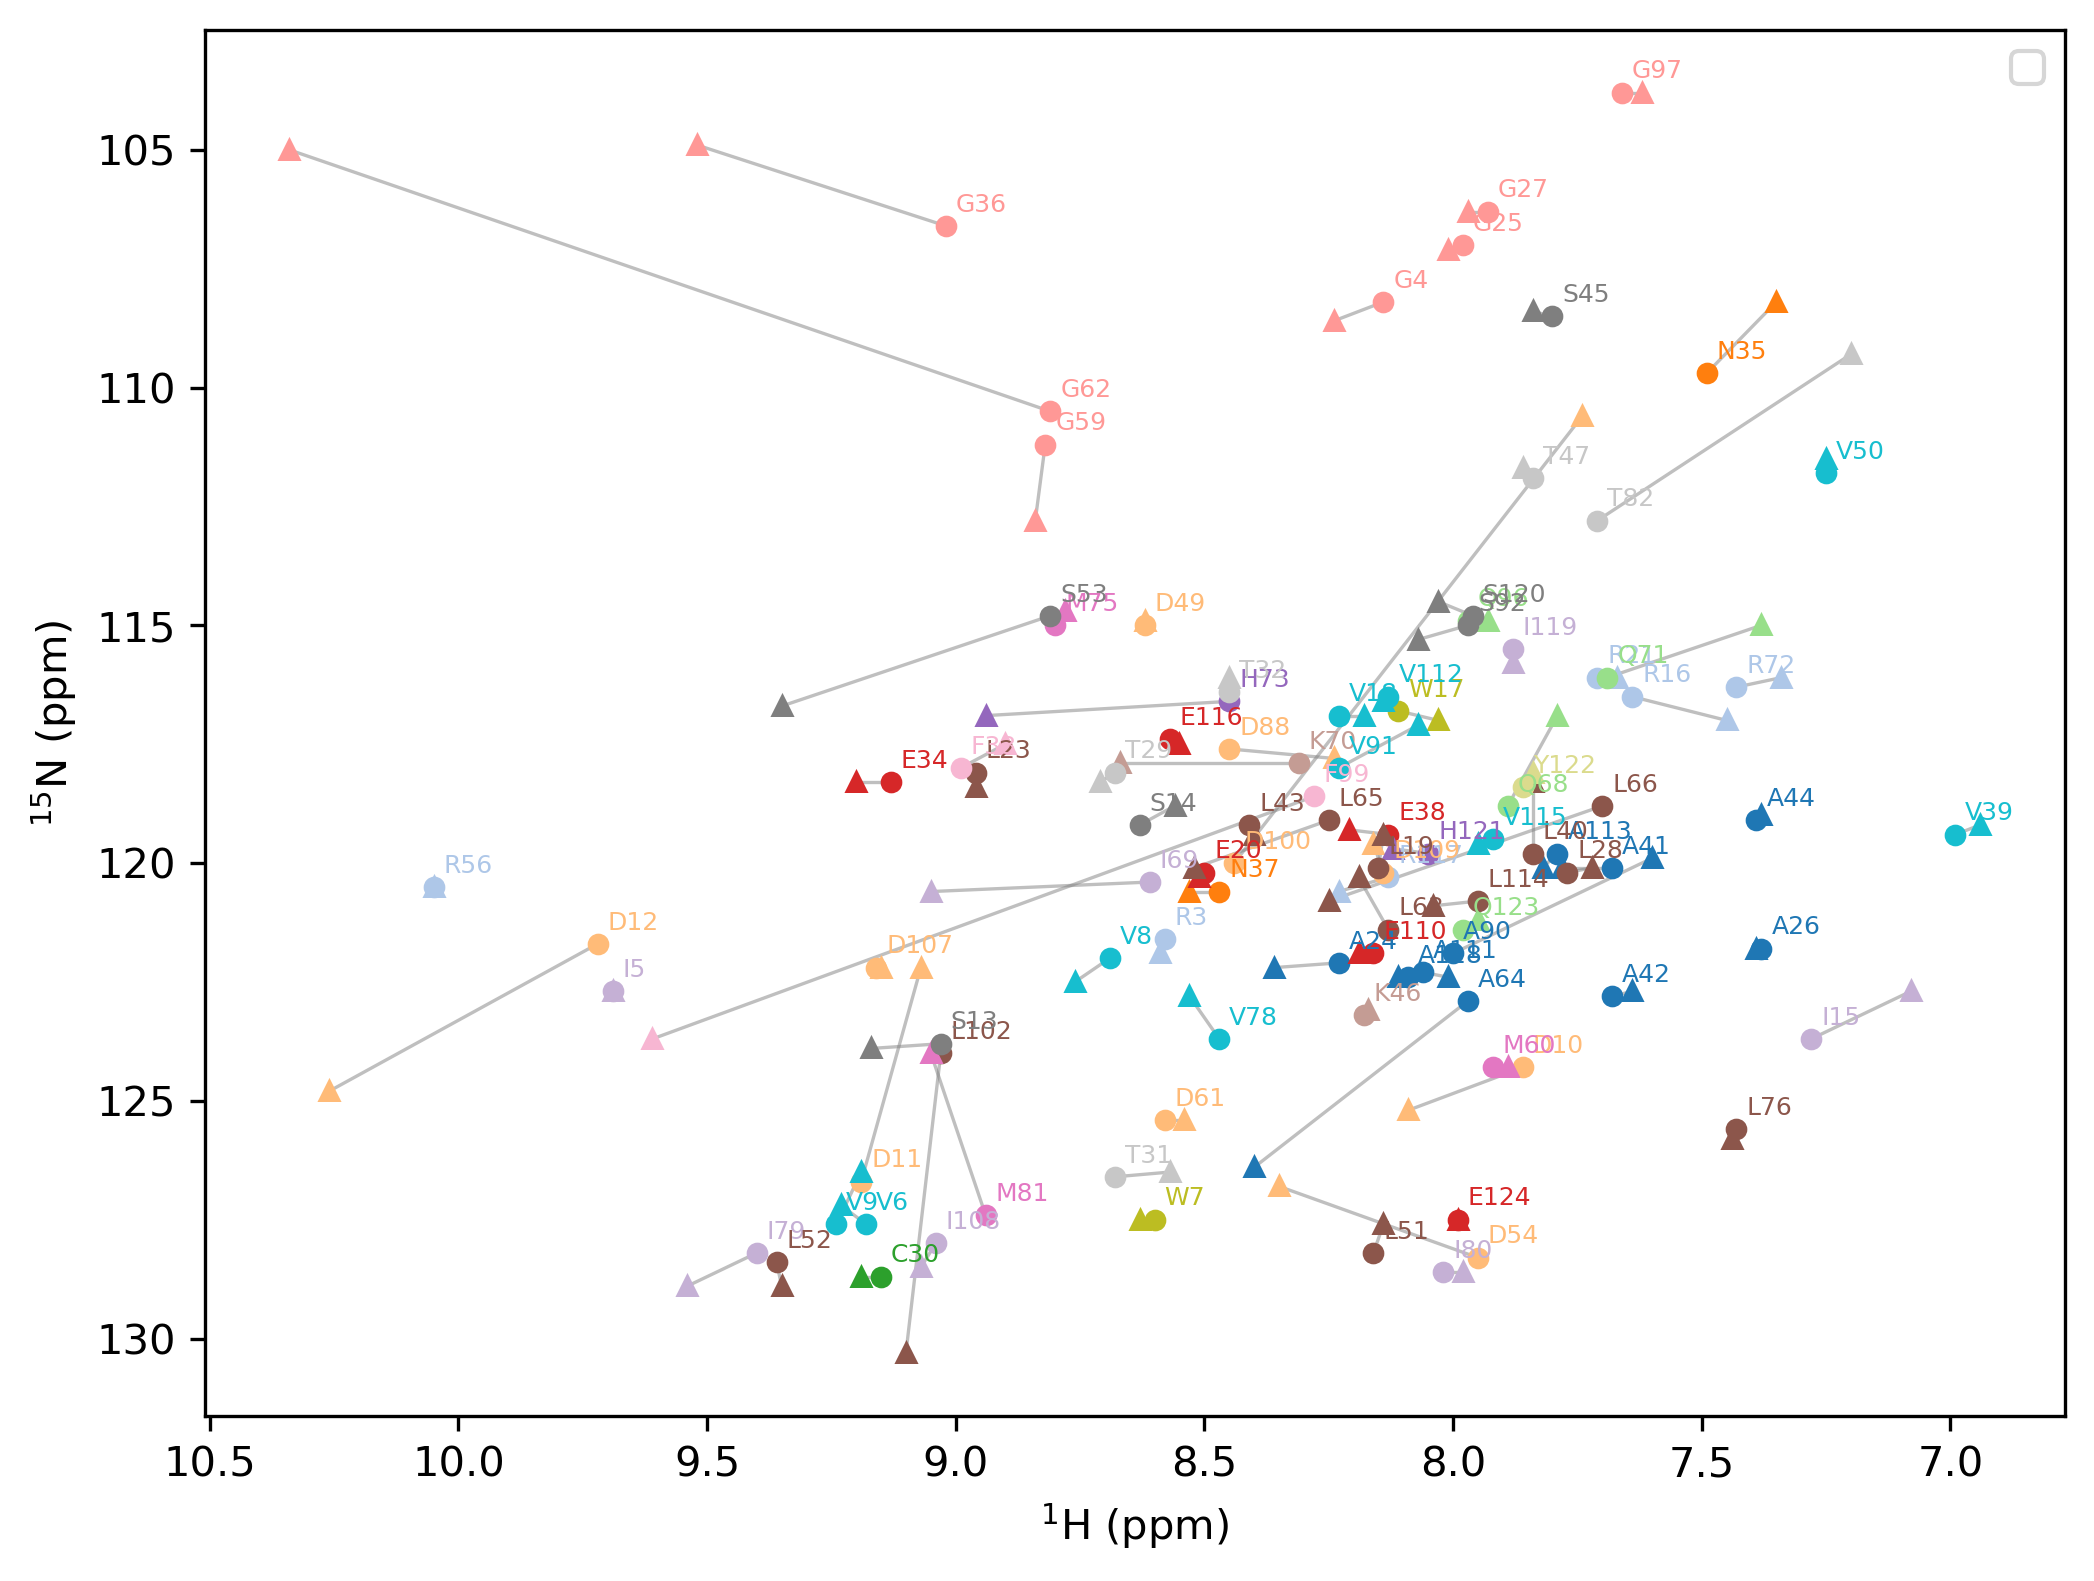

In [6]:
fig, ax = plot_csp(cs.peaklist().data, cs_phos.peaklist().data,
                   on='assn_label', text='assn_label',hue='Comp_ID',palette='tab20')
plt.legend([])

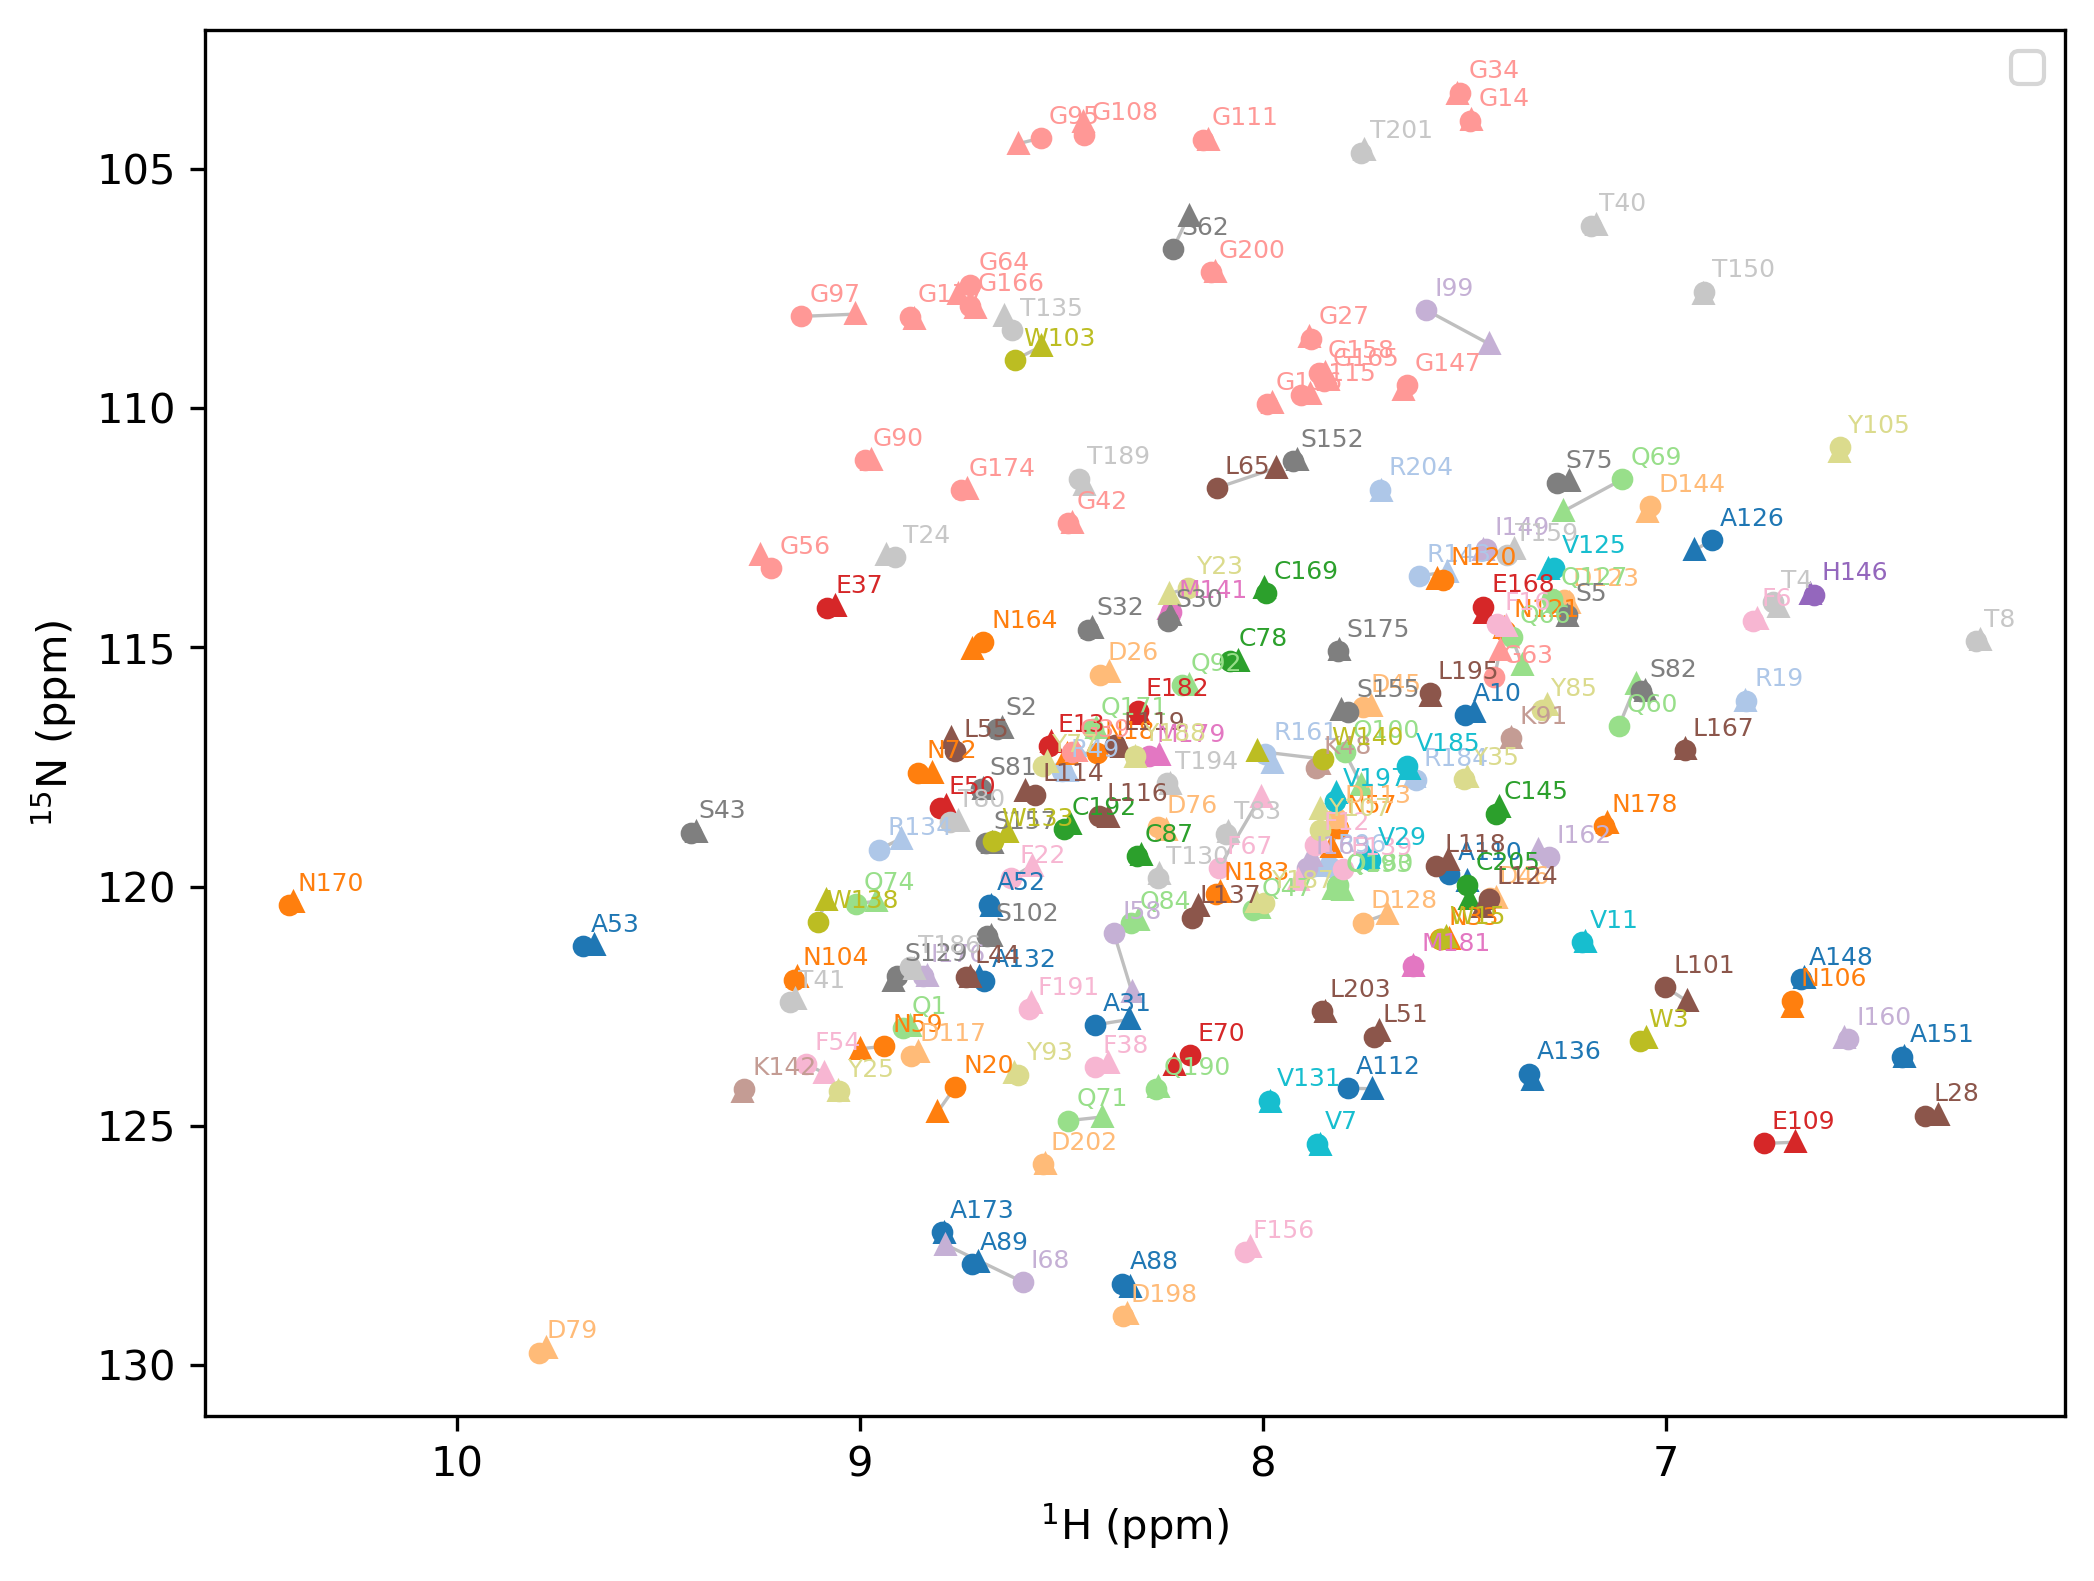

In [5]:
#another example: Chi19a

cs_wt = ms.ChemicalShifts.from_bmrb(11441) #Chi19a WT
cs_mut = ms.ChemicalShifts.from_bmrb(11466) #Chi19a dead mutant E61A

fig, ax = plot_csp(cs_wt.peaklist().data, cs_mut.peaklist().data,
                   on='assn_label', text='assn_label',hue='Comp_ID',palette='tab20')
plt.legend([])

## 3. Multi-entity entries

Some entries hold several entities (protein + DNA + ligand). `sequences()` lists them.

In [4]:
# hERR2 zinc finger bound to DNA
cs = ms.ChemicalShifts.from_bmrb(5363)
cs.sequences()

,entity,ID,Polymer_type,Polymer_seq_one_letter_code
0,hERR2,1,polypeptide(L),AIPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPAT...
1,DNA_strand1,2,polydeoxyribonucleotide,GCTCAAGGTCACG
2,DNA_strand2,3,polydeoxyribonucleotide,CGTGACCTTGAGC
3,ZN,4,.,.


In [5]:
# keep only the polypeptide entity
ents = cs.sequences()
protein_ids = ents.loc[ents['Polymer_type'] == 'polypeptide(L)', 'ID']
cs.data[cs.data['Entity_ID'].isin(protein_ids)].head()

,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,ChemShift_ID
0,1,1,97,ALA,CA,C,49.85,chemical_shifts_1
1,1,1,97,ALA,HA,H,4.11,chemical_shifts_1
2,1,1,97,ALA,CB,C,20.08,chemical_shifts_1
3,1,1,97,ALA,HB1,H,1.48,chemical_shifts_1
4,1,1,97,ALA,HB2,H,1.48,chemical_shifts_1


## 4. Chemical Shift Index (CSI)

`calc_csi=True` adds `csi_raw` (the (CA−CB) secondary shift: positive = helix, negative = strand) and `csi` (discretised to ±1 / 0).

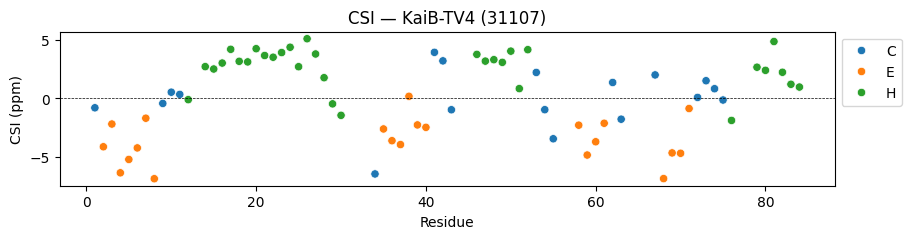

In [6]:
# KaiB-TV4 — known secondary structure
cs = ms.ChemicalShifts.from_bmrb(31107, calc_csi=True)

seq = 'MYVFRLYVRGETHAAEVALKNLHDLLSSALKVPYTLKVVDVTKQPDLAEKDQVQATPTLVRVYPQPVRRLVGQLDHRYRLQHLLSP'
dss = 'CEEEEEEECCCHHHHHHHHHHHHHHHHHHHCCCCEEEEEECCCHHHHHHHHHCCCCCEEEECCCCCCEEEECCCCHHHHHHHHHHC'

tmp = cs.data[cs.data['Atom_type'] == 'N'].copy()
tmp['dssp'] = tmp['Seq_ID'].map(lambda i: dss[i - 1])

plt.figure(figsize=(10, 2))
sns.scatterplot(x='Seq_ID', y='csi_raw', hue='dssp', data=tmp)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.xlabel('Residue'); plt.ylabel('CSI (ppm)')
plt.title('CSI — KaiB-TV4 (31107)'); plt.legend(bbox_to_anchor=(1, 1))

# 5. Check sample conditions

In [11]:
# Denatured 
cs = ms.ChemicalShifts.from_bmrb(51260)
e = cs.entry

e.sample_info()


,sample,ID,Sample_ID,Mol_common_name,Entity_ID,Isotopic_labeling,Concentration_val,Concentration_val_units
0,sample_1,1,1,'Helix 1 from HHR23A ubiquitin-associated doma...,1,'[U-13C; U-15N]',0.21,mM
1,sample_1,2,1,'sodium phosphate',.,'natural abundance',50,mM
2,sample_1,3,1,NaCl,.,'natural abundance',100,mM
3,sample_1,4,1,'guanidine hydrochloride',.,'natural abundance',4,M
4,sample_2,1,2,'Helix 1 from HHR23A ubiquitin-associated doma...,1,'[U-13C; U-15N]',0.21,mM
5,sample_2,2,2,'sodium phosphate',.,'natural abundance',50,mM
6,sample_2,3,2,NaCl,.,'natural abundance',100,mM
7,sample_2,4,2,'guanidine hydrochloride',.,'natural abundance',5,M
8,sample_3,1,3,'Helix 1 from HHR23A ubiquitin-associated doma...,1,'[U-13C; U-15N]',0.21,mM
9,sample_3,2,3,'sodium phosphate',.,'natural abundance',50,mM


In [12]:
# check if denatured, methyl labeled, or deuterated
from functools import reduce
reduce(lambda a, b: a.merge(b, on=["sample", "Sample_ID", "Entity_ID"]),
    [e.is_deuterated(), e.is_methyl_labeled(), e.is_denatured()])

,sample,Sample_ID,Entity_ID,deuterated,methyl_labeled,denatured
0,sample_1,1,1,False,False,True
1,sample_2,2,1,False,False,True
2,sample_3,3,1,False,False,True
3,sample_4,4,1,False,False,True
